For Figure (G)

In [20]:
"""
TIFF stack -> Optical flow speed map on full image
- No mask
- No crop
- Pixel-wise speed colormap over entire image
- Additional quiver plot with arrow color mapped by speed
"""

import os
import numpy as np
import cv2
import tifffile as tiff
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import colors
from mpl_toolkits.axes_grid1 import make_axes_locatable


# ===================== User Settings =====================

TIF_STACK_PATH = r"D:\MCF10A_honeycomb_spreading\data_pre\0128_CMOS.tif"
OUT_DIR        = r"C:\Users\oxfil\speed_map_full_image_JUN17"
OUT_BASENAME   = "full_image_speed_map_0616"

# Unit conversion
UM_PER_PX = 10
DT_MIN    = 11.3

# Image display
CMAP_CELL = "Blues_r"
CELL_VMIN = 35
CELL_VMAX = 70

# Speed colormap
CMAP_SPEED = "turbo"
SPEED_VMIN = 0.0
SPEED_VMAX_MODE = 1.0   # "global" | "per_frame" | float
# Quiver colormap
CMAP_quiver = "YlOrRd"

# Figure
DPI = 600
FIGSIZE = (6, 6)
SHOW_COLORBAR = True
SPEED_ALPHA = 1.0

# Quiver plot
MAKE_QUIVER = True
QUIVER_STEP = 6                # spacing between arrows
QUIVER_SCALE = 0.075             # larger = shorter arrows
QUIVER_WIDTH = 0.0010
QUIVER_ALPHA = 1.0
QUIVER_MIN_SPEED = 0.05         # hide arrows below this speed (in displayed unit)
QUIVER_BGCELL_ALPHA = 1.0
USE_PHYSICAL_UNITS_FOR_QUIVER = False
# False: arrow length = px/frame, arrow color = µm/min
# True : arrow length = µm/min, arrow color = µm/min

# Optical flow parameters
FB_PARAMS = dict(
    pyr_scale=0.5,
    levels=1,
    winsize=7,
    iterations=2,
    poly_n=5,
    poly_sigma=1.2,
    flags=0
)

# =========================================================


def _to_gray_float(img):
    """Convert image to float32 grayscale."""
    if img.ndim == 3:
        if img.shape[2] == 3:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        elif img.shape[2] == 4:
            img = cv2.cvtColor(img, cv2.COLOR_BGRA2GRAY)
        else:
            img = np.mean(img, axis=2)
    return img.astype(np.float32, copy=False)


def _load_tif_frames(path):
    """Load TIFF as frame stack."""
    arr = tiff.imread(path)

    if arr.ndim == 2:
        return arr[None, ...]

    H, W = arr.shape[-2], arr.shape[-1]
    n = arr.size // (H * W)

    return arr.reshape(n, H, W)


def _compute_flow(prev, nxt):
    """Compute optical flow."""
    return cv2.calcOpticalFlowFarneback(prev, nxt, None, **FB_PARAMS)


def _speed_to_units(speed_px_per_frame):
    """Convert px/frame to µm/min if calibration exists."""
    if UM_PER_PX is not None and DT_MIN is not None and DT_MIN > 0:
        return speed_px_per_frame * UM_PER_PX / DT_MIN
    return speed_px_per_frame


def _flow_to_units(flow_px_per_frame):
    """Convert flow vectors from px/frame to µm/min if calibration exists."""
    if UM_PER_PX is not None and DT_MIN is not None and DT_MIN > 0:
        factor = UM_PER_PX / DT_MIN
        return flow_px_per_frame * factor
    return flow_px_per_frame


def _speed_label():
    if UM_PER_PX is not None and DT_MIN is not None:
        return "Speed (µm/min)"
    return "Speed (px/frame)"


def _compute_global_speed_vmax(frames):
    """
    Compute global vmax from the full image.
    Uses 99th percentile to avoid extreme outliers.
    """
    vmax = 0.0

    for i in range(len(frames) - 1):
        prev = _to_gray_float(frames[i])
        nxt = _to_gray_float(frames[i + 1])

        flow = _compute_flow(prev, nxt)
        speed_px = np.sqrt(flow[..., 0] ** 2 + flow[..., 1] ** 2)
        speed_units = _speed_to_units(speed_px)

        vals = speed_units[np.isfinite(speed_units)]

        if len(vals) > 0:
            vmax = max(vmax, float(np.nanpercentile(vals, 99)))

    return max(vmax, 1e-8)


def plot_speed_map_full_image(base, speed_map, out_png, vmax_speed):
    """
    Plot base image in gray and speed map over the entire image.
    """
    cmap_cell = matplotlib.colormaps.get_cmap(CMAP_CELL)
    cmap_speed = matplotlib.colormaps.get_cmap(CMAP_SPEED).copy()

    norm_speed = colors.Normalize(
        vmin=SPEED_VMIN,
        vmax=vmax_speed,
        clip=True
    )

    fig, ax = plt.subplots(figsize=FIGSIZE, dpi=DPI)

    ax.imshow(
        base,
        cmap=cmap_cell,
        vmin=CELL_VMIN,
        vmax=CELL_VMAX,
        interpolation="nearest"
    )

    im = ax.imshow(
        speed_map,
        cmap=cmap_speed,
        norm=norm_speed,
        alpha=SPEED_ALPHA,
        interpolation="nearest"
    )

    if SHOW_COLORBAR:
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="4%", pad=0.04)
        cbar = fig.colorbar(im, cax=cax)
        cbar.set_label(_speed_label())

    ax.set_axis_off()
    ax.set_title("Pixel-wise speed map on full image")

    fig.savefig(out_png, bbox_inches="tight")
    plt.close(fig)


def plot_quiver_speed_full_image(base, flow, speed_map, out_png, vmax_speed):
    """
    Plot base image with quiver vectors.
    Arrow color is mapped by speed magnitude.
    """
    cmap_cell = matplotlib.colormaps.get_cmap(CMAP_CELL)
    cmap_quiver = matplotlib.colormaps.get_cmap(CMAP_quiver).copy()

    norm_speed = colors.Normalize(
        vmin=SPEED_VMIN,
        vmax=vmax_speed,
        clip=True
    )

    fig, ax = plt.subplots(figsize=FIGSIZE, dpi=DPI)

    ax.imshow(
        base,
        cmap=cmap_cell,
        vmin=CELL_VMIN,
        vmax=CELL_VMAX,
        alpha=QUIVER_BGCELL_ALPHA,
        interpolation="nearest"
    )

    H, W = base.shape

    # Downsample grid
    yy, xx = np.mgrid[0:H:QUIVER_STEP, 0:W:QUIVER_STEP]

    u = flow[0:H:QUIVER_STEP, 0:W:QUIVER_STEP, 0]
    v = flow[0:H:QUIVER_STEP, 0:W:QUIVER_STEP, 1]
    s = speed_map[0:H:QUIVER_STEP, 0:W:QUIVER_STEP]

    # Valid arrows
    valid = np.isfinite(s) & np.isfinite(u) & np.isfinite(v) & (s >= QUIVER_MIN_SPEED)

    xx_q = xx[valid]
    yy_q = yy[valid]
    u_q = u[valid]
    v_q = v[valid]
    s_q = s[valid]

    q = ax.quiver(
        xx_q,
        yy_q,
        u_q,
        v_q,
        s_q,
        cmap=cmap_quiver,
        norm=norm_speed,
        angles="xy",
        scale_units="xy",
        scale=QUIVER_SCALE,
        width=QUIVER_WIDTH,
        alpha=QUIVER_ALPHA
    )

    if SHOW_COLORBAR:
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="4%", pad=0.04)
        cbar = fig.colorbar(q, cax=cax)
        cbar.set_label(_speed_label())

    ax.set_xlim(0, W)
    ax.set_ylim(H, 0)
    ax.set_aspect("equal")
    ax.set_axis_off()
    ax.set_title("Optical flow quiver map colored by speed")

    fig.savefig(out_png, bbox_inches="tight")
    plt.close(fig)


def main():
    os.makedirs(OUT_DIR, exist_ok=True)

    frames = _load_tif_frames(TIF_STACK_PATH)

    print(f"[INFO] Loaded frames: {frames.shape}")

    # Speed vmax
    if isinstance(SPEED_VMAX_MODE, (int, float)):
        vmax_speed = float(SPEED_VMAX_MODE)

    elif SPEED_VMAX_MODE == "global":
        print("[INFO] Computing global speed vmax on full image...")
        vmax_speed = _compute_global_speed_vmax(frames)
        print(f"[INFO] Global speed vmax = {vmax_speed:.4g}")

    elif SPEED_VMAX_MODE == "per_frame":
        vmax_speed = None

    else:
        raise ValueError("SPEED_VMAX_MODE should be 'global', 'per_frame', or float.")

    # Process each frame pair
    for i in range(len(frames) - 1):
        base = _to_gray_float(frames[i])
        nxt = _to_gray_float(frames[i + 1])

        flow_px = _compute_flow(base, nxt)

        speed_px = np.sqrt(flow_px[..., 0] ** 2 + flow_px[..., 1] ** 2)
        speed_units = _speed_to_units(speed_px)

        if SPEED_VMAX_MODE == "per_frame":
            vals = speed_units[np.isfinite(speed_units)]
            this_vmax = float(np.nanpercentile(vals, 99)) if len(vals) > 0 else 1.0
            this_vmax = max(this_vmax, 1e-8)
        else:
            this_vmax = vmax_speed

        # Heatmap output
        out_png = os.path.join(
            OUT_DIR,
            f"{OUT_BASENAME}_t{i:04d}.png"
        )

        plot_speed_map_full_image(
            base=base,
            speed_map=speed_units,
            out_png=out_png,
            vmax_speed=this_vmax
        )

        print(f"[Saved] {out_png}")

        # Quiver output
        if MAKE_QUIVER:
            if USE_PHYSICAL_UNITS_FOR_QUIVER:
                flow_for_quiver = _flow_to_units(flow_px)
            else:
                flow_for_quiver = flow_px

            out_quiver_png = os.path.join(
                OUT_DIR,
                f"{OUT_BASENAME}_quiver_t{i:04d}.png"
            )

            plot_quiver_speed_full_image(
                base=base,
                flow=flow_for_quiver,
                speed_map=speed_units,
                out_png=out_quiver_png,
                vmax_speed=this_vmax
            )

            print(f"[Saved] {out_quiver_png}")

    print(f"[DONE] Saved outputs in: {OUT_DIR}")


if __name__ == "__main__":
    main()

[INFO] Loaded frames: (102, 1024, 1024)
[Saved] C:\Users\oxfil\speed_map_full_image_JUN17\full_image_speed_map_0616_t0000.png
[Saved] C:\Users\oxfil\speed_map_full_image_JUN17\full_image_speed_map_0616_quiver_t0000.png
[Saved] C:\Users\oxfil\speed_map_full_image_JUN17\full_image_speed_map_0616_t0001.png
[Saved] C:\Users\oxfil\speed_map_full_image_JUN17\full_image_speed_map_0616_quiver_t0001.png
[Saved] C:\Users\oxfil\speed_map_full_image_JUN17\full_image_speed_map_0616_t0002.png
[Saved] C:\Users\oxfil\speed_map_full_image_JUN17\full_image_speed_map_0616_quiver_t0002.png
[Saved] C:\Users\oxfil\speed_map_full_image_JUN17\full_image_speed_map_0616_t0003.png
[Saved] C:\Users\oxfil\speed_map_full_image_JUN17\full_image_speed_map_0616_quiver_t0003.png
[Saved] C:\Users\oxfil\speed_map_full_image_JUN17\full_image_speed_map_0616_t0004.png
[Saved] C:\Users\oxfil\speed_map_full_image_JUN17\full_image_speed_map_0616_quiver_t0004.png
[Saved] C:\Users\oxfil\speed_map_full_image_JUN17\full_image_spee

In [87]:
"""
TIFF stack -> user-selected line kymograph
1) image intensity kymograph along selected line
2) optical-flow velocity kymograph along selected line
3) speed kymograph along selected line
4) normal velocity kymograph along selected line

- Click two points on SELECT_FRAME
- Kymograph x-axis: distance along selected line
- Kymograph y-axis: time
"""

import os
import numpy as np
import cv2
import tifffile as tiff
import matplotlib.pyplot as plt


# ============================================================
# USER SETTINGS
# ============================================================

IMAGE_PATH = r"D:\MCF10A_honeycomb_spreading\data_pre\0128_CMOS.tif"
OUTPUT_DIR = r"D:\MCF10A_honeycomb_spreading\data_pre\output_line_kymograph"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# plot time range
PLOT_TIME_START_MIN = 60       
PLOT_TIME_END_MIN   = 960     

# pixel/time conversion
UM_PER_PX = 10
MIN_PER_FRAME = 11.3

# line selection
SELECT_FRAME = 29         
LINE_WIDTH_PX = 10     
N_BINS = None             

# image display
CMAP_IMAGE = "Blues_r"

# velocity display
CMAP_VELOCITY = "seismic"
CMAP_SPEED = "turbo"

# manual color scale
IMAGE_VMIN = 35
IMAGE_VMAX = 70

VEL_VMIN = -60         
VEL_VMAX = 60           

SPEED_VMIN = 0
SPEED_VMAX = 60       

# optical flow parameters
FARNEBACK_PARAMS = dict(
    pyr_scale=0.5,
    levels=3,
    winsize=7,
    iterations=3,
    poly_n=5,
    poly_sigma=1.2,
    flags=0
)

# save check images
SAVE_FLOW_CHECK = True
FLOW_CHECK_STEP_FRAME = 20
QUIVER_STEP = 20


# ============================================================
# LOAD FUNCTIONS
# ============================================================


def crop_kymograph_by_time(kymo, time_step_min, start_min=None, end_min=None):
    """
    kymo: T x X
    time_step_min: minutes per frame
    start_min, end_min: plot range
    """
    T = kymo.shape[0]

    if start_min is None:
        start_idx = 0
    else:
        start_idx = int(np.floor(start_min / time_step_min))
        start_idx = max(start_idx, 0)

    if end_min is None:
        end_idx = T
    else:
        end_idx = int(np.ceil(end_min / time_step_min)) + 1
        end_idx = min(end_idx, T)

    if start_idx >= end_idx:
        raise ValueError(
            f"Invalid time range: start_idx={start_idx}, end_idx={end_idx}. "
            f"Check PLOT_TIME_START_MIN and PLOT_TIME_END_MIN."
        )

    cropped = kymo[start_idx:end_idx]

    actual_start_min = start_idx * time_step_min
    actual_end_min = (end_idx - 1) * time_step_min

    return cropped, actual_start_min, actual_end_min


def load_image_stack_raw_and_uint8(path):
    """
    Returns
    -------
    raw_stack : float32, shape T,H,W
        Original intensity stack, only converted to float.
    uint8_stack : uint8, shape T,H,W
        Frame-wise normalized stack for optical flow.
    """
    img = tiff.imread(path)

    if img.ndim == 2:
        img = img[None, :, :]

    elif img.ndim == 3:
        # likely T,H,W when first axis is smaller than spatial axes
        if img.shape[0] < img.shape[1] and img.shape[0] < img.shape[2]:
            pass
        else:
            # possible H,W,T
            img = np.moveaxis(img, -1, 0)

    elif img.ndim == 4:
        # assume T,H,W,C
        img = img[..., :3]
        img = np.mean(img, axis=-1)

    raw_stack = img.astype(np.float32)

    uint8_frames = []
    for frame in raw_stack:
        f = frame.copy()
        f = f - np.nanmin(f)
        denom = np.nanmax(f)
        if denom > 0:
            f = f / denom
        f = (f * 255).astype(np.uint8)
        uint8_frames.append(f)

    uint8_stack = np.stack(uint8_frames, axis=0)

    return raw_stack, uint8_stack


# ============================================================
# LINE SELECTION
# ============================================================

def select_axis_line(frame, frame_id=None):
    plt.figure(figsize=(8, 8))
    plt.imshow(frame, cmap="gray")

    title = "Click two points to define the kymograph line\nPoint 1 = left/start, Point 2 = right/end"
    if frame_id is not None:
        title = f"Frame {frame_id}: " + title

    plt.title(title)
    pts = plt.ginput(2, timeout=0)
    plt.close()

    if len(pts) != 2:
        raise RuntimeError("You must click exactly two points.")

    p1 = np.array(pts[0], dtype=float)  # x,y
    p2 = np.array(pts[1], dtype=float)  # x,y

    return p1, p2


def save_selected_line_check(frame, p1, p2, outdir):
    plt.figure(figsize=(8, 8))
    plt.imshow(frame, cmap="gray")
    plt.plot([p1[0], p2[0]], [p1[1], p2[1]], "r-", linewidth=2)
    plt.scatter([p1[0]], [p1[1]], c="blue", s=50, label="start")
    plt.scatter([p2[0]], [p2[1]], c="red", s=50, label="end")
    plt.title("Selected line for kymograph")
    plt.axis("off")
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.savefig(os.path.join(outdir, "selected_line_check.png"), dpi=300)
    plt.close()


# ============================================================
# GEOMETRY
# ============================================================

def get_axis_coordinates(shape, p1, p2):
    """
    p1, p2 are x,y.
    Returns s, n, axis_unit, normal_unit, axis_len.

    s: projected distance along selected line, in px
    n: signed distance from selected line, in px
    """
    H, W = shape
    yy, xx = np.indices((H, W))

    coords = np.stack([xx, yy], axis=-1).astype(float)

    axis_vec = p2 - p1
    axis_len = np.linalg.norm(axis_vec)

    if axis_len == 0:
        raise ValueError("Selected line length is zero.")

    axis_unit = axis_vec / axis_len
    normal_unit = np.array([-axis_unit[1], axis_unit[0]])

    rel = coords - p1

    s = rel[..., 0] * axis_unit[0] + rel[..., 1] * axis_unit[1]
    n = rel[..., 0] * normal_unit[0] + rel[..., 1] * normal_unit[1]

    return s, n, axis_unit, normal_unit, axis_len


def make_line_bins(axis_len, n_bins=None):
    if n_bins is None:
        n_bins = int(np.ceil(axis_len))

    edges = np.linspace(0, axis_len, n_bins + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])

    return edges, centers


def average_map_along_line(value_map, s, n, axis_len, line_width_px, bin_edges):
    """
    value_map: H,W
    Returns 1D profile along selected line.
    """
    valid = (
        np.isfinite(value_map)
        & (s >= 0)
        & (s <= axis_len)
        & (np.abs(n) <= line_width_px / 2)
    )

    profile = np.full(len(bin_edges) - 1, np.nan, dtype=np.float32)

    s_valid = s[valid]
    values_valid = value_map[valid]

    if len(values_valid) == 0:
        return profile

    bin_id = np.digitize(s_valid, bin_edges) - 1

    for b in range(len(profile)):
        vals = values_valid[bin_id == b]
        if len(vals) > 0:
            profile[b] = np.nanmean(vals)

    return profile


# ============================================================
# KYMOGRAPH CALCULATION
# ============================================================

def compute_image_kymograph(raw_stack, p1, p2):
    T, H, W = raw_stack.shape

    s, n, axis_unit, normal_unit, axis_len = get_axis_coordinates((H, W), p1, p2)
    bin_edges, bin_centers_px = make_line_bins(axis_len, N_BINS)

    image_kymo = []

    for t in range(T):
        profile = average_map_along_line(
            value_map=raw_stack[t],
            s=s,
            n=n,
            axis_len=axis_len,
            line_width_px=LINE_WIDTH_PX,
            bin_edges=bin_edges
        )
        image_kymo.append(profile)

    image_kymo = np.stack(image_kymo, axis=0)

    return image_kymo, bin_centers_px, axis_len


def compute_flow_kymographs(uint8_stack, p1, p2):
    T, H, W = uint8_stack.shape

    s, n, axis_unit, normal_unit, axis_len = get_axis_coordinates((H, W), p1, p2)
    bin_edges, bin_centers_px = make_line_bins(axis_len, N_BINS)

    factor = UM_PER_PX * 60.0 / MIN_PER_FRAME

    axis_vel_kymo = []
    normal_vel_kymo = []
    speed_kymo = []

    for t in range(T - 1):
        frame1 = uint8_stack[t]
        frame2 = uint8_stack[t + 1]

        flow = cv2.calcOpticalFlowFarneback(
            frame1,
            frame2,
            None,
            **FARNEBACK_PARAMS
        )

        flow_x = flow[..., 0]
        flow_y = flow[..., 1]

        # projected displacement, px/frame
        v_axis_px = flow_x * axis_unit[0] + flow_y * axis_unit[1]
        v_normal_px = flow_x * normal_unit[0] + flow_y * normal_unit[1]
        speed_px = np.sqrt(flow_x**2 + flow_y**2)

        # convert to velocity, um/h
        v_axis = v_axis_px * factor
        v_normal = v_normal_px * factor
        speed = speed_px * factor

        axis_profile = average_map_along_line(
            value_map=v_axis,
            s=s,
            n=n,
            axis_len=axis_len,
            line_width_px=LINE_WIDTH_PX,
            bin_edges=bin_edges
        )

        normal_profile = average_map_along_line(
            value_map=v_normal,
            s=s,
            n=n,
            axis_len=axis_len,
            line_width_px=LINE_WIDTH_PX,
            bin_edges=bin_edges
        )

        speed_profile = average_map_along_line(
            value_map=speed,
            s=s,
            n=n,
            axis_len=axis_len,
            line_width_px=LINE_WIDTH_PX,
            bin_edges=bin_edges
        )

        axis_vel_kymo.append(axis_profile)
        normal_vel_kymo.append(normal_profile)
        speed_kymo.append(speed_profile)

        if SAVE_FLOW_CHECK and (t % FLOW_CHECK_STEP_FRAME == 0):
            save_flow_check_image(
                frame=frame1,
                flow_x=flow_x,
                flow_y=flow_y,
                p1=p1,
                p2=p2,
                s=s,
                n=n,
                axis_len=axis_len,
                t=t,
                outdir=OUTPUT_DIR
            )

    axis_vel_kymo = np.stack(axis_vel_kymo, axis=0)
    normal_vel_kymo = np.stack(normal_vel_kymo, axis=0)
    speed_kymo = np.stack(speed_kymo, axis=0)

    return axis_vel_kymo, normal_vel_kymo, speed_kymo, bin_centers_px, axis_len


# ============================================================
# SAVE / PLOT FUNCTIONS
# ============================================================

def robust_limits(data, vmin=None, vmax=None, low=1, high=99):
    finite = data[np.isfinite(data)]

    if len(finite) == 0:
        return vmin, vmax

    if vmin is None:
        vmin = np.percentile(finite, low)
    if vmax is None:
        vmax = np.percentile(finite, high)

    return vmin, vmax


def save_kymograph_plot(
    kymo,
    outdir,
    basename,
    title,
    cmap,
    vmin=None,
    vmax=None,
    ylabel="Time",
    cbar_label="Value",
    bin_centers_px=None,
    time_step_min=None,
    symmetric=False,
    plot_start_min=None,
    plot_end_min=None
):
    plot_data = kymo.copy()

    if time_step_min is not None:
        plot_data, actual_start_min, actual_end_min = crop_kymograph_by_time(
            plot_data,
            time_step_min=time_step_min,
            start_min=plot_start_min,
            end_min=plot_end_min
        )
    else:
        actual_start_min = 0
        actual_end_min = plot_data.shape[0] - 1

    if symmetric:
        finite = plot_data[np.isfinite(plot_data)]
        if len(finite) > 0:
            lim = np.nanpercentile(np.abs(finite), 99)
            if vmin is None:
                vmin = -lim
            if vmax is None:
                vmax = lim

    vmin, vmax = robust_limits(plot_data, vmin=vmin, vmax=vmax)

    if bin_centers_px is not None:
        x_um = bin_centers_px * UM_PER_PX
        x_min = x_um[0]
        x_max = x_um[-1]
    else:
        x_min = 0
        x_max = plot_data.shape[1] - 1

    if time_step_min is not None:
        y_min = actual_start_min
        y_max = actual_end_min
    else:
        y_min = 0
        y_max = plot_data.shape[0] - 1

    plt.figure(figsize=(9, 5))
    im = plt.imshow(
        plot_data,
        aspect="auto",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        origin="lower",
        extent=[x_min, x_max, y_min, y_max]
    )

    plt.xlabel("Distance along selected line (µm)")
    plt.ylabel(ylabel)
    plt.title(title)

    cbar = plt.colorbar(im)
    cbar.set_label(cbar_label)

    plt.tight_layout()
    plt.savefig(os.path.join(outdir, f"{basename}.png"), dpi=300)
    plt.savefig(os.path.join(outdir, f"{basename}.pdf"))
    plt.close()


def save_kymograph_data(kymo, outdir, basename):
    np.save(os.path.join(outdir, f"{basename}.npy"), kymo.astype(np.float32))
    tiff.imwrite(os.path.join(outdir, f"{basename}.tif"), kymo.astype(np.float32))


def save_flow_check_image(frame, flow_x, flow_y, p1, p2, s, n, axis_len, t, outdir):
    H, W = frame.shape

    line_region = (
        (s >= 0)
        & (s <= axis_len)
        & (np.abs(n) <= LINE_WIDTH_PX / 2)
    )

    yy, xx = np.mgrid[0:H:QUIVER_STEP, 0:W:QUIVER_STEP]
    u = flow_x[::QUIVER_STEP, ::QUIVER_STEP]
    v = flow_y[::QUIVER_STEP, ::QUIVER_STEP]
    region_small = line_region[::QUIVER_STEP, ::QUIVER_STEP]

    plt.figure(figsize=(8, 8))
    plt.imshow(frame, cmap="gray")
    plt.contour(line_region, colors="cyan", linewidths=0.7)
    plt.plot([p1[0], p2[0]], [p1[1], p2[1]], "r-", linewidth=2)
    plt.scatter([p1[0]], [p1[1]], c="blue", s=40, label="start")
    plt.scatter([p2[0]], [p2[1]], c="red", s=40, label="end")

    plt.quiver(
        xx[region_small],
        yy[region_small],
        u[region_small],
        v[region_small],
        angles="xy",
        scale_units="xy",
        scale=1,
        width=0.003
    )

    plt.title(f"Optical flow check near selected line - frame {t}")
    plt.axis("off")
    plt.legend(loc="upper right")
    plt.tight_layout()

    save_path = os.path.join(outdir, f"flow_check_line_frame_{t:04d}.png")
    plt.savefig(save_path, dpi=200)
    plt.close()


def save_metadata(outdir, p1, p2, axis_len, bin_centers_px):
    txt_path = os.path.join(outdir, "kymograph_metadata.txt")

    with open(txt_path, "w") as f:
        f.write(f"IMAGE_PATH: {IMAGE_PATH}\n")
        f.write(f"UM_PER_PX: {UM_PER_PX}\n")
        f.write(f"MIN_PER_FRAME: {MIN_PER_FRAME}\n")
        f.write(f"SELECT_FRAME: {SELECT_FRAME}\n")
        f.write(f"LINE_WIDTH_PX: {LINE_WIDTH_PX}\n")
        f.write(f"N_BINS: {len(bin_centers_px)}\n")
        f.write(f"p1_x,p1_y: {p1[0]}, {p1[1]}\n")
        f.write(f"p2_x,p2_y: {p2[0]}, {p2[1]}\n")
        f.write(f"axis_len_px: {axis_len}\n")
        f.write(f"axis_len_um: {axis_len * UM_PER_PX}\n")
        f.write("FARNEBACK_PARAMS:\n")
        for k, v in FARNEBACK_PARAMS.items():
            f.write(f"  {k}: {v}\n")


# ============================================================
# MAIN
# ============================================================

raw_stack, uint8_stack = load_image_stack_raw_and_uint8(IMAGE_PATH)

T, H, W = raw_stack.shape
print(f"[INFO] raw stack shape: {raw_stack.shape}")
print(f"[INFO] uint8 stack shape: {uint8_stack.shape}")

if SELECT_FRAME >= T:
    raise ValueError(f"SELECT_FRAME={SELECT_FRAME} is outside stack length T={T}")

# select line
p1, p2 = select_axis_line(raw_stack[SELECT_FRAME], frame_id=SELECT_FRAME)
save_selected_line_check(raw_stack[SELECT_FRAME], p1, p2, OUTPUT_DIR)

print(f"[INFO] selected p1: {p1}")
print(f"[INFO] selected p2: {p2}")

# image kymograph
image_kymo, bin_centers_px_img, axis_len_img = compute_image_kymograph(raw_stack, p1, p2)

# flow kymographs
axis_vel_kymo, normal_vel_kymo, speed_kymo, bin_centers_px_flow, axis_len_flow = compute_flow_kymographs(
    uint8_stack,
    p1,
    p2
)

# save raw data
save_kymograph_data(image_kymo, OUTPUT_DIR, "image_kymograph")
save_kymograph_data(axis_vel_kymo, OUTPUT_DIR, "axis_velocity_kymograph_um_per_h")
save_kymograph_data(normal_vel_kymo, OUTPUT_DIR, "normal_velocity_kymograph_um_per_h")
save_kymograph_data(speed_kymo, OUTPUT_DIR, "speed_kymograph_um_per_h")

# save plots
save_kymograph_plot(
    kymo=image_kymo,
    outdir=OUTPUT_DIR,
    basename="image_kymograph",
    title="Image intensity kymograph along selected line",
    cmap=CMAP_IMAGE,
    vmin=IMAGE_VMIN,
    vmax=IMAGE_VMAX,
    ylabel="Time (min)",
    cbar_label="Intensity",
    bin_centers_px=bin_centers_px_img,
    time_step_min=MIN_PER_FRAME,
    symmetric=False,
    plot_start_min=PLOT_TIME_START_MIN,
    plot_end_min=PLOT_TIME_END_MIN
)

save_kymograph_plot(
    kymo=axis_vel_kymo,
    outdir=OUTPUT_DIR,
    basename="axis_velocity_kymograph_um_per_h",
    title="Axis-projected velocity kymograph",
    cmap=CMAP_VELOCITY,
    vmin=VEL_VMIN,
    vmax=VEL_VMAX,
    ylabel="Time (min)",
    cbar_label="Velocity along line (µm/h)",
    bin_centers_px=bin_centers_px_flow,
    time_step_min=MIN_PER_FRAME,
    symmetric=True,
    plot_start_min=PLOT_TIME_START_MIN,
    plot_end_min=PLOT_TIME_END_MIN
)

save_kymograph_plot(
    kymo=normal_vel_kymo,
    outdir=OUTPUT_DIR,
    basename="normal_velocity_kymograph_um_per_h",
    title="Normal velocity kymograph",
    cmap=CMAP_VELOCITY,
    vmin=VEL_VMIN,
    vmax=VEL_VMAX,
    ylabel="Time (min)",
    cbar_label="Velocity normal to line (µm/h)",
    bin_centers_px=bin_centers_px_flow,
    time_step_min=MIN_PER_FRAME,
    symmetric=True
)

save_kymograph_plot(
    kymo=speed_kymo,
    outdir=OUTPUT_DIR,
    basename="speed_kymograph_um_per_h",
    title="Speed kymograph",
    cmap=CMAP_SPEED,
    vmin=SPEED_VMIN,
    vmax=SPEED_VMAX,
    ylabel="Time (min)",
    cbar_label="Speed (µm/h)",
    bin_centers_px=bin_centers_px_flow,
    time_step_min=MIN_PER_FRAME,
    symmetric=False,
    plot_start_min=PLOT_TIME_START_MIN,
    plot_end_min=PLOT_TIME_END_MIN
)

save_metadata(OUTPUT_DIR, p1, p2, axis_len_img, bin_centers_px_img)

print("[DONE]")
print(f"Saved outputs to: {OUTPUT_DIR}")
print(f"Image kymograph shape: {image_kymo.shape}")
print(f"Velocity kymograph shape: {axis_vel_kymo.shape}")

[INFO] raw stack shape: (102, 1024, 1024)
[INFO] uint8 stack shape: (102, 1024, 1024)
[INFO] selected p1: [224.91298701 379.17792208]
[INFO] selected p2: [391.14675325 385.82727273]
[DONE]
Saved outputs to: D:\MCF10A_honeycomb_spreading\data_pre\output_line_kymograph
Image kymograph shape: (102, 167)
Velocity kymograph shape: (101, 167)


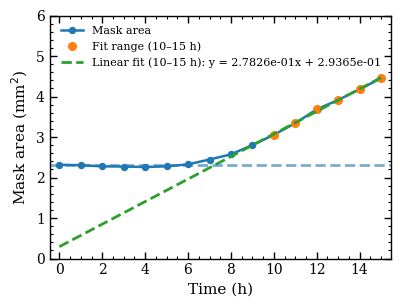

Saved PDF: D:\MCF10A_honeycomb_spreading\data_pre\mask_area_vs_time_APS_from_csv.pdf
Loaded area CSV: D:\MCF10A_honeycomb_spreading\data_pre\mask_area_vs_time_data_optical.csv
Loaded fit CSV: D:\MCF10A_honeycomb_spreading\data_pre\mask_area_linear_fit_summary.csv
Linear fit range = 10.00 to 15.00 h
Displayed fit line = 0 to 15.00 h
Slope = 2.782626e-01 mm^2/h
Intercept = 2.936475e-01 mm^2


In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

# =========================
# USER SETTINGS
# =========================
AREA_CSV = r"D:\MCF10A_honeycomb_spreading\data_pre\mask_area_vs_time_data_optical.csv"
FIT_CSV  = r"D:\MCF10A_honeycomb_spreading\data_pre\mask_area_linear_fit_summary.csv"

OUT_PDF = r"D:\MCF10A_honeycomb_spreading\data_pre\mask_area_vs_time_APS_from_csv.pdf"

# Plot time limit
MAX_TIME_HOUR = 15.0

# If True, extend fit line to full plotted time range
EXTEND_FIT_TO_MAX_TIME = False

# Plot styling
FIG_W, FIG_H = 4.2, 3.2
LINE_W = 1.8
MARKER_SIZE = 4.5
FONT_SIZE = 11

Y_LIM = (0, 6.0)
# =========================


def apply_aps_style():
    plt.rcParams.update({
        "font.family": "serif",
        "font.size": FONT_SIZE,
        "axes.linewidth": 1.0,
        "axes.labelsize": FONT_SIZE,
        "xtick.labelsize": FONT_SIZE - 1,
        "ytick.labelsize": FONT_SIZE - 1,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.major.size": 5,
        "ytick.major.size": 5,
        "xtick.minor.size": 2.5,
        "ytick.minor.size": 2.5,
        "xtick.major.width": 1.0,
        "ytick.major.width": 1.0,
        "xtick.minor.width": 0.8,
        "ytick.minor.width": 0.8,
        "legend.frameon": False,
        "pdf.fonttype": 42,
        "ps.fonttype": 42
    })


def main():
    apply_aps_style()

    area_df = pd.read_csv(AREA_CSV)
    fit_df = pd.read_csv(FIT_CSV)

    required_area_cols = {
        "time_hr",
        "area_mm2",
        "area_mm2_plot",
        "is_fit_range"
    }

    required_fit_cols = {
        "fit_start_hour",
        "fit_end_hour",
        "slope_mm2_per_hour",
        "intercept_mm2",
        "initial_area_mm2"
    }

    if not required_area_cols.issubset(area_df.columns):
        raise ValueError(f"AREA_CSV must contain columns: {required_area_cols}")

    if not required_fit_cols.issubset(fit_df.columns):
        raise ValueError(f"FIT_CSV must contain columns: {required_fit_cols}")

    if MAX_TIME_HOUR is not None:
        area_df = area_df[area_df["time_hr"] <= MAX_TIME_HOUR].copy()

    time_hr = area_df["time_hr"].values
    y_plot = area_df["area_mm2_plot"].values
    fit_mask = area_df["is_fit_range"].astype(bool).values

    fit_start_hour = float(fit_df["fit_start_hour"].iloc[0])
    fit_end_hour = float(fit_df["fit_end_hour"].iloc[0])
    slope = float(fit_df["slope_mm2_per_hour"].iloc[0])
    intercept = float(fit_df["intercept_mm2"].iloc[0])
    initial_area = float(fit_df["initial_area_mm2"].iloc[0])

    if EXTEND_FIT_TO_MAX_TIME:
        line_end_hr = time_hr.max()
    else:
        line_end_hr = fit_end_hour

    x_fit_line = np.linspace(0, line_end_hr, 300)
    y_fit_line = slope * x_fit_line + intercept

    x_fit = time_hr[fit_mask]
    y_fit = y_plot[fit_mask]

    fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))

    ax.plot(
        time_hr,
        y_plot,
        "-o",
        lw=LINE_W,
        ms=MARKER_SIZE,
        markeredgewidth=0.8,
        label="Mask area"
    )

    ax.plot(
        x_fit,
        y_fit,
        "o",
        ms=MARKER_SIZE + 1,
        label=f"Fit range ({fit_start_hour:.0f}–{fit_end_hour:.0f} h)"
    )

    ax.plot(
        x_fit_line,
        y_fit_line,
        "--",
        lw=2.0,
        label=(
            f"Linear fit ({fit_start_hour:.0f}–{fit_end_hour:.0f} h): "
            f"y = {slope:.4e}x + {intercept:.4e}"
        )
    )

    ax.axhline(
        initial_area,
        ls="--",
        lw=2.0,
        alpha=0.6
    )

    ax.set_xlabel("Time (h)")
    ax.set_ylabel(r"Mask area (mm$^2$)")

    if Y_LIM is not None:
        ax.set_ylim(*Y_LIM)

    ax.tick_params(which="both", top=True, right=True)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())

    ax.margins(x=0.03, y=0.08)
    ax.legend(loc="best", fontsize=8)

    plt.tight_layout()

    os.makedirs(os.path.dirname(OUT_PDF), exist_ok=True)
    plt.savefig(OUT_PDF, dpi=300, bbox_inches="tight", transparent=True)
    plt.show()

    print(f"Saved PDF: {OUT_PDF}")
    print(f"Loaded area CSV: {AREA_CSV}")
    print(f"Loaded fit CSV: {FIT_CSV}")
    print(f"Linear fit range = {fit_start_hour:.2f} to {fit_end_hour:.2f} h")
    print(f"Displayed fit line = 0 to {line_end_hr:.2f} h")
    print(f"Slope = {slope:.6e} mm^2/h")
    print(f"Intercept = {intercept:.6e} mm^2")


if __name__ == "__main__":
    main()

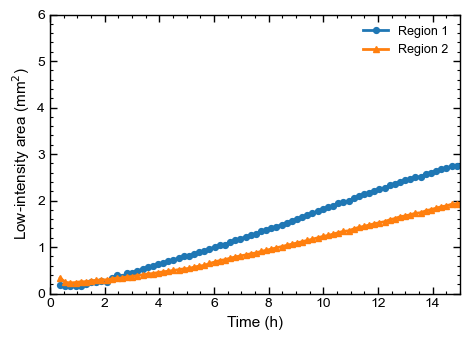

Saved: pos1_low_intensity_area_vs_time_mm2.pdf
Using um_per_pixel = 10.0
Frame interval = 11.3 min = 0.1883 h
Region1: first = 0.179700 mm^2, last = 3.447500 mm^2
Region2: first = 0.336600 mm^2, last = 2.541900 mm^2


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import AutoMinorLocator

# ========= publication-friendly PDF =========
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype']  = 42
mpl.rcParams['font.family']  = 'Arial'

# ===================== EDIT ME =====================
CSV_PATH = "low_intensity_area_over_time_by_region.csv"

FRAME_TO_MIN = 11.3
FRAME_TO_HOUR = FRAME_TO_MIN / 60.0

UM_PER_PIXEL = 10.0
START_FRAME = 2 
# pos filtering
USE_POS_FILTER = False     
POS_COL = "position"        
POS_VALUE = "pos1"

COL_T  = "t"
COL_A1 = "region1_low_area_px"
COL_A2 = "region2_low_area_px"

OUT_PDF = "pos1_low_intensity_area_vs_time_mm2.pdf"
# ================================================


def px_to_mm2(area_px, um_per_pixel=10.0):
    area_px = np.asarray(area_px, dtype=float)
    return area_px * (um_per_pixel ** 2) / 1e6


def apply_aps_style():
    mpl.rcParams.update({
        "axes.linewidth": 1.0,
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.major.size": 5,
        "ytick.major.size": 5,
        "xtick.minor.size": 2.5,
        "ytick.minor.size": 2.5,
        "xtick.major.width": 1.0,
        "ytick.major.width": 1.0,
        "xtick.minor.width": 0.8,
        "ytick.minor.width": 0.8,
        "legend.frameon": False,
    })


def main():
    apply_aps_style()

    df = pd.read_csv(CSV_PATH)
    if USE_POS_FILTER:
        if POS_COL not in df.columns:
            raise ValueError(f"'{POS_COL}' column not found in CSV.")
        df = df[df[POS_COL].astype(str) == str(POS_VALUE)].copy()

    if df.empty:
        raise ValueError("No rows left after filtering. Check POS_COL / POS_VALUE.")

    # 시간축
    t = df[COL_T].to_numpy(dtype=float)
    t = t[START_FRAME:]
    time_hr = t * FRAME_TO_HOUR

    # area values from CSV (already computed within mask-defined region)
    A1_px = df[COL_A1].to_numpy(dtype=float)[START_FRAME:]
    A2_px = df[COL_A2].to_numpy(dtype=float)[START_FRAME:]

    A1_mm2 = px_to_mm2(A1_px, UM_PER_PIXEL)
    A2_mm2 = px_to_mm2(A2_px, UM_PER_PIXEL)

    # ---- plot ----
    fig, ax = plt.subplots(figsize=(4.8, 3.5))

    ax.plot(
        time_hr, A1_mm2,
        marker='o', linestyle='-',
        linewidth=2.0, markersize=4.2,
        label="Region 1"
    )
    ax.plot(
        time_hr, A2_mm2,
        marker='^', linestyle='-',
        linewidth=2.0, markersize=4.2,
        label="Region 2"
    )

    ax.set_xlabel("Time (h)")
    ax.set_ylabel(r"Low-intensity area (mm$^2$)")
    ax.set_ylim(0, 6.0)
    ax.set_xlim(0, 15.0) 

    ax.tick_params(which='both', top=True, right=True)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())

    ax.margins(x=0.03, y=0.08)
    ax.legend(fontsize=9, loc="best")

    plt.tight_layout()
    plt.savefig(OUT_PDF, format="pdf", bbox_inches="tight", transparent=True)
    plt.show()

    print("Saved:", OUT_PDF)
    print(f"Using um_per_pixel = {UM_PER_PIXEL}")
    print(f"Frame interval = {FRAME_TO_MIN} min = {FRAME_TO_HOUR:.4f} h")
    print(f"Region1: first = {A1_mm2[0]:.6f} mm^2, last = {A1_mm2[-1]:.6f} mm^2")
    print(f"Region2: first = {A2_mm2[0]:.6f} mm^2, last = {A2_mm2[-1]:.6f} mm^2")


if __name__ == "__main__":
    main()